# 第十课：正则化与防过拟合

## 什么是过拟合？

| 现象 | 训练集表现 | 测试集表现 |
|------|-----------|-----------|
| 欠拟合 | 差 | 差 |
| 正常 | 好 | 好 |
| 过拟合 | 很好 | 差 |

过拟合 = 模型记住了训练数据的细节和噪声，但没有学到真正的规律。

## 防过拟合的主要方法

| 方法 | 原理 |
|------|------|
| Dropout | 随机丢弃神经元，减少共适应 |
| BatchNorm | 标准化中间层输出，稳定训练 |
| 权重衰减 (L2) | 惩罚大权重，限制模型复杂度 |
| 早停 (Early Stopping) | 验证集性能不提升时停止训练 |
| 数据增强 | 扩充训练数据 |
| 减小模型 | 降低模型容量 |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split

## 1. 构造过拟合场景

用小数据集 + 大模型来演示过拟合。

In [2]:
torch.manual_seed(42)

n_samples = 200
X = torch.randn(n_samples, 20)
W_true = torch.randn(20, 3) * 0.5
logits = X @ W_true
y = logits.argmax(dim=1)

full_dataset = TensorDataset(X, y)
train_size = 40
val_size = 40
test_size = n_samples - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print(f"训练集: {train_size}, 验证集: {val_size}, 测试集: {test_size}")
print("小训练集 + 大模型 = 容易过拟合")

训练集: 40, 验证集: 40, 测试集: 120
小训练集 + 大模型 = 容易过拟合


In [3]:
# 大模型（容易过拟合）
class OverfitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
    
    def forward(self, x):
        return self.net(x)

def train_model(model, train_loader, val_loader, epochs=200, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            total += X_batch.size(0)
        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)
        
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_correct += (logits.argmax(dim=1) == y_batch).sum().item()
                val_total += X_batch.size(0)
        val_losses.append(val_loss / val_total)
        val_accs.append(val_correct / val_total)
    
    return train_losses, val_losses, train_accs, val_accs

torch.manual_seed(42)
overfit_model = OverfitModel()
train_l, val_l, train_a, val_a = train_model(overfit_model, train_loader, val_loader)

print(f"训练准确率: {train_a[-1]:.4f}, 验证准确率: {val_a[-1]:.4f}")
print(f"训练损失: {train_l[-1]:.4f}, 验证损失: {val_l[-1]:.4f}")
print("\n训练准确率远高于验证准确率 → 过拟合！")

训练准确率: 1.0000, 验证准确率: 0.5250
训练损失: 0.0001, 验证损失: 2.2378

训练准确率远高于验证准确率 → 过拟合！


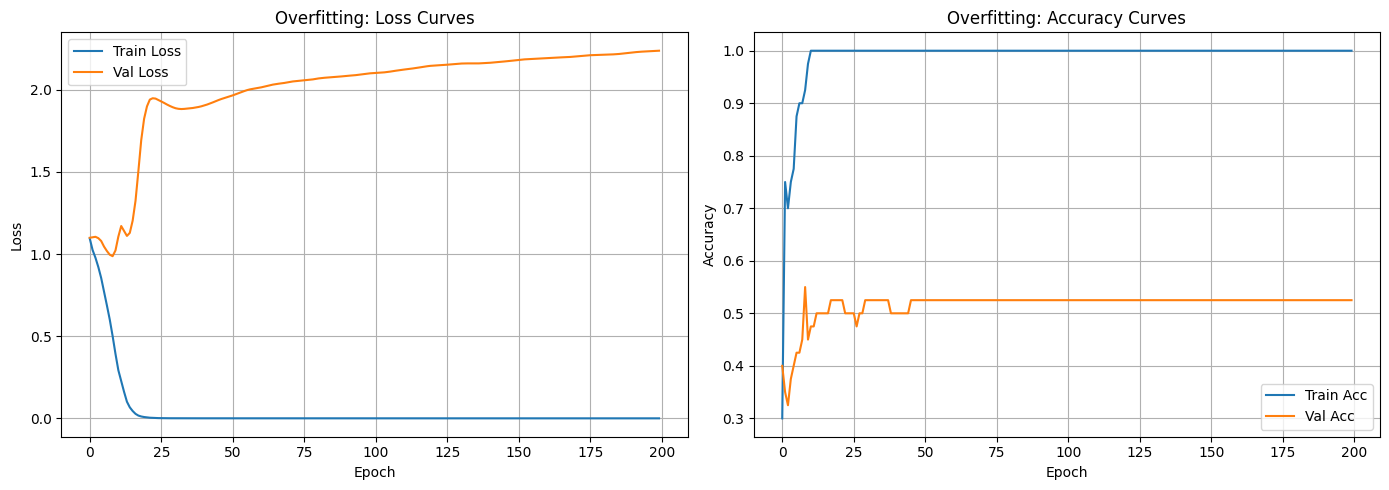

典型过拟合特征:
  训练损失持续下降，验证损失先降后升
  训练准确率接近100%，验证准确率远低于训练


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_l, label='Train Loss')
axes[0].plot(val_l, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Overfitting: Loss Curves')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_a, label='Train Acc')
axes[1].plot(val_a, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Overfitting: Accuracy Curves')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("典型过拟合特征:")
print("  训练损失持续下降，验证损失先降后升")
print("  训练准确率接近100%，验证准确率远低于训练")

---
## 2. Dropout

Dropout 在训练时随机将部分神经元输出置零，迫使网络不依赖任何单个神经元。

```
训练时: 每个神经元以概率 p 被"关闭"（输出置0）
推理时: 所有神经元都工作，但输出乘以 (1-p) 来补偿
```

PyTorch 自动处理推理时的缩放，我们只需在模型中加 `nn.Dropout(p)`。

In [ ]:
# Dropout 演示
dropout = nn.Dropout(p=0.5)
x = torch.ones(10)

print(f"原始输入: {x.numpy()}")
print(f"\n训练模式 (dropout 生效):")
dropout.train()
for i in range(3):
    print(f"  {dropout(x).numpy().round(2)}")

print(f"\n评估模式 (dropout 不生效):")
dropout.eval()
print(f"  {dropout(x).numpy().round(2)}")

print("\n训练时约一半神经元被置0，其余值放大2倍（保持期望不变）")
print("评估时所有神经元正常工作")

In [ ]:
# 带 Dropout 的模型
class DropoutModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 3)
        )
    
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
dropout_model = DropoutModel(dropout_rate=0.3)
d_train_l, d_val_l, d_train_a, d_val_a = train_model(dropout_model, train_loader, val_loader)

print(f"无Dropout - 训练: {train_a[-1]:.4f}, 验证: {val_a[-1]:.4f}")
print(f"有Dropout - 训练: {d_train_a[-1]:.4f}, 验证: {d_val_a[-1]:.4f}")
print("\nDropout 降低了训练准确率，但提高了验证准确率 → 减少过拟合")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(val_l, label='No Dropout (Val)', color='red')
axes[0].plot(d_val_l, label='With Dropout (Val)', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('Dropout Effect on Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_a, label='No Dropout', color='red')
axes[1].plot(d_val_a, label='With Dropout', color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Dropout Effect on Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 不同 dropout 率对比
dropout_rates = [0.0, 0.1, 0.3, 0.5]
dropout_results = {}

for rate in dropout_rates:
    torch.manual_seed(42)
    model = DropoutModel(dropout_rate=rate)
    _, vl, _, va = train_model(model, train_loader, val_loader)
    dropout_results[f'p={rate}'] = (vl, va)
    print(f"Dropout p={rate}: 验证 acc={va[-1]:.4f}, 验证 loss={vl[-1]:.4f}")

print("\n常用 dropout 率: 0.1~0.5")
print("太大(>0.5)会欠拟合，太小(<0.1)效果不明显")

## 3. Batch Normalization

BatchNorm 对每个 mini-batch 的中间层输出做标准化：

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y = \gamma \hat{x} + \beta$$

- $\mu_B, \sigma_B$：当前 batch 的均值和方差
- $\gamma, \beta$：可学习的缩放和偏移参数

好处：
- 稳定训练，允许使用更大学习率
- 减少对初始化的敏感度
- 有轻微正则化效果
- 加速收敛

In [ ]:
# BatchNorm 用法
class BNModel(nn.Module):
    def __init__(self, use_bn=True):
        super().__init__()
        layers = []
        in_dim = 20
        for hidden_dim in [256, 256, 128]:
            layers.append(nn.Linear(in_dim, hidden_dim))
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            in_dim = hidden_dim
        layers.append(nn.Linear(128, 3))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
bn_model = BNModel(use_bn=True)
no_bn_model = BNModel(use_bn=False)

bn_train_l, bn_val_l, bn_train_a, bn_val_a = train_model(bn_model, train_loader, val_loader, lr=0.005)
nbn_train_l, nbn_val_l, nbn_train_a, nbn_val_a = train_model(no_bn_model, train_loader, val_loader, lr=0.005)

print(f"无BN - 训练: {nbn_train_a[-1]:.4f}, 验证: {nbn_val_a[-1]:.4f}")
print(f"有BN - 训练: {bn_train_a[-1]:.4f}, 验证: {bn_val_a[-1]:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nbn_train_l, label='No BN (Train)', color='red', alpha=0.5)
axes[0].plot(nbn_val_l, label='No BN (Val)', color='red')
axes[0].plot(bn_train_l, label='With BN (Train)', color='blue', alpha=0.5)
axes[0].plot(bn_val_l, label='With BN (Val)', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BatchNorm Effect on Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nbn_val_a, label='No BN', color='red')
axes[1].plot(bn_val_a, label='With BN', color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('BatchNorm Effect on Val Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("BatchNorm 通常加速收敛，使训练更稳定")
print("位置: Linear -> BatchNorm -> ReLU (在激活函数之前)")

In [ ]:
# BatchNorm 的注意事项
print("=== BatchNorm 注意事项 ===")
print()
print("1. 训练/推理行为不同:")
print("   训练: 用当前 batch 的均值和方差")
print("   推理: 用训练时累积的运行均值和方差")
print("   所以 model.train() / model.eval() 很重要！")
print()
print("2. batch_size 太小时效果不好:")
print("   batch 统计量不稳定，建议 batch_size >= 16")
print()
print("3. 不同维度的 BatchNorm:")
print("   nn.BatchNorm1d: 全连接层 (batch, features)")
print("   nn.BatchNorm2d: 卷积层 (batch, channels, H, W)")
print("   nn.LayerNorm:   Transformer (对特征维度归一化)")
print()
print("4. BatchNorm vs LayerNorm:")
print("   BatchNorm: 沿 batch 维度归一化（同一特征跨样本）")
print("   LayerNorm: 沿 feature 维度归一化（同一样本跨特征）")
print("   CNN 常用 BatchNorm，Transformer 常用 LayerNorm")

## 4. 权重衰减（Weight Decay / L2 正则化）

In [ ]:
# 权重衰减原理
print("=== 权重衰减 (Weight Decay) ===")
print()
print("在损失函数中加入权重的 L2 惩罚:")
print("  Loss_total = Loss_original + (weight_decay / 2) * ||w||^2")
print()
print("效果: 惩罚大权重，使权重趋向较小的值")
print("直觉: 权重越小，模型越简单，越不容易过拟合")
print()
print("PyTorch 中的使用:")
print("  optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)")
print("  optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)")
print("  optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)  # 推荐")
print()
print("常用值: 1e-4 ~ 1e-2")
print("AdamW 比 Adam + weight_decay 更好（解耦更新）")

In [ ]:
# 权重衰减对比
wd_values = [0, 1e-4, 1e-3, 1e-2]
wd_results = {}

for wd in wd_values:
    torch.manual_seed(42)
    model = OverfitModel()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=wd)
    
    tl, vl, ta, va = [], [], [], []
    for epoch in range(200):
        model.train()
        el, c, t = 0, 0, 0
        for X_batch, y_batch in train_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            el += loss.item() * X_batch.size(0)
            c += (logits.argmax(dim=1) == y_batch).sum().item()
            t += X_batch.size(0)
        tl.append(el/t); ta.append(c/t)
        
        model.eval()
        vle, vc, vt = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                vle += loss.item() * X_batch.size(0)
                vc += (logits.argmax(dim=1) == y_batch).sum().item()
                vt += X_batch.size(0)
        vl.append(vle/vt); va.append(vc/vt)
    
    wd_results[f'wd={wd}'] = (vl, va)
    print(f"weight_decay={wd:6.0e}: 验证 acc={va[-1]:.4f}, 验证 loss={vl[-1]:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (vl, va) in wd_results.items():
    axes[0].plot(vl, label=name, alpha=0.8)
    axes[1].plot(va, label=name, alpha=0.8)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('Weight Decay Effect on Val Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Weight Decay Effect on Val Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. 早停（Early Stopping）

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False
        self.best_state = None
    
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

print("EarlyStopping: 验证损失连续 patience 个 epoch 不下降则停止")
print("并恢复到最佳模型参数")

In [ ]:
# 使用早停训练
torch.manual_seed(42)
model = OverfitModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
early_stopping = EarlyStopping(patience=15)

es_train_l, es_val_l, es_train_a, es_val_a = [], [], [], []
stopped_epoch = 0

for epoch in range(500):
    model.train()
    el, c, t = 0, 0, 0
    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        el += loss.item() * X_batch.size(0)
        c += (logits.argmax(dim=1) == y_batch).sum().item()
        t += X_batch.size(0)
    es_train_l.append(el/t); es_train_a.append(c/t)
    
    model.eval()
    vle, vc, vt = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            vle += loss.item() * X_batch.size(0)
            vc += (logits.argmax(dim=1) == y_batch).sum().item()
            vt += X_batch.size(0)
    es_val_l.append(vle/vt); es_val_a.append(vc/vt)
    
    early_stopping(vle/vt, model)
    if early_stopping.should_stop:
        stopped_epoch = epoch + 1
        break

if early_stopping.best_state:
    model.load_state_dict(early_stopping.best_state)

print(f"早停在 epoch {stopped_epoch} 停止训练")
print(f"最佳验证 loss: {early_stopping.best_loss:.4f}")
print(f"最终验证 acc: {es_val_a[-1]:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(es_train_l, label='Train Loss')
axes[0].plot(es_val_l, label='Val Loss')
axes[0].axvline(x=stopped_epoch-1, color='r', linestyle='--', label=f'Stopped (epoch {stopped_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Early Stopping: Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(es_train_a, label='Train Acc')
axes[1].plot(es_val_a, label='Val Acc')
axes[1].axvline(x=stopped_epoch-1, color='r', linestyle='--', label=f'Stopped (epoch {stopped_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Early Stopping: Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. 综合对比：所有正则化方法

In [ ]:
class RegularizedModel(nn.Module):
    def __init__(self, dropout_rate=0.3, use_bn=True):
        super().__init__()
        layers = []
        in_dim = 20
        for hidden_dim in [256, 256, 128]:
            layers.append(nn.Linear(in_dim, hidden_dim))
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = hidden_dim
        layers.append(nn.Linear(128, 3))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

configs = {
    'No Regularization': {'dropout_rate': 0, 'use_bn': False, 'wd': 0},
    'Dropout Only':      {'dropout_rate': 0.3, 'use_bn': False, 'wd': 0},
    'BN Only':           {'dropout_rate': 0, 'use_bn': True, 'wd': 0},
    'Weight Decay Only': {'dropout_rate': 0, 'use_bn': False, 'wd': 1e-3},
    'All Combined':      {'dropout_rate': 0.3, 'use_bn': True, 'wd': 1e-3},
}

all_results = {}

for name, cfg in configs.items():
    torch.manual_seed(42)
    model = RegularizedModel(dropout_rate=cfg['dropout_rate'], use_bn=cfg['use_bn'])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=cfg['wd'])
    
    tl, vl, ta, va = [], [], [], []
    for epoch in range(200):
        model.train()
        el, c, t = 0, 0, 0
        for X_batch, y_batch in train_loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            el += loss.item() * X_batch.size(0)
            c += (logits.argmax(dim=1) == y_batch).sum().item()
            t += X_batch.size(0)
        tl.append(el/t); ta.append(c/t)
        
        model.eval()
        vle, vc, vt = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                vle += loss.item() * X_batch.size(0)
                vc += (logits.argmax(dim=1) == y_batch).sum().item()
                vt += X_batch.size(0)
        vl.append(vle/vt); va.append(vc/vt)
    
    all_results[name] = (vl, va)
    print(f"{name:25s}: 验证 acc={va[-1]:.4f}, 验证 loss={vl[-1]:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (vl, va) in all_results.items():
    axes[0].plot(vl, label=name, alpha=0.8)
    axes[1].plot(va, label=name, alpha=0.8)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('Regularization Comparison: Val Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Regularization Comparison: Val Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("组合多种正则化方法通常效果最好")

---
## 总结

### 正则化方法速查

| 方法 | 使用方式 | 典型参数 | 适用场景 |
|------|----------|----------|----------|
| Dropout | `nn.Dropout(p)` | p=0.1~0.5 | 全连接层、RNN |
| BatchNorm | `nn.BatchNorm1d/2d` | 无需调参 | CNN、全连接 |
| LayerNorm | `nn.LayerNorm` | 无需调参 | Transformer |
| Weight Decay | optimizer 的参数 | 1e-4~1e-2 | 通用 |
| Early Stopping | 自定义类 | patience=10~20 | 通用 |
| 数据增强 | torchvision.transforms | - | 图像 |

### 最佳实践

```
1. 先不加正则化，确认模型能过拟合训练集
2. 逐步加入正则化，观察验证集表现
3. 常用组合: BatchNorm + Dropout + Weight Decay
4. 始终使用 Early Stopping
5. 数据增强是图像任务最有效的正则化
```

### ⚠️ 常见错误
- 忘记 model.eval()：Dropout 和 BatchNorm 在训练/推理时行为不同
- Dropout 加在最后一层之前，不要加在输出层
- Weight Decay 值太大导致欠拟合
- BatchNorm 的 batch_size 太小